### Using randomly generated  (whether patient has AF) to predict the next dependant variable (being on an anticoagulant)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random as rn
import seaborn as sns 

In [5]:
num_samples=1000

In [6]:
df_a=pd.read_csv("combo_anticoag_afib.csv", index_col="afib_anticoagulant")

In [7]:
df_a

,0,1
afib_anticoagulant,,
0,0.76744,0.06481
1,0.03264,0.13511


In [8]:
q=df_a.loc[0,"0"]
r=df_a.loc[0,"1"]
s=df_a.loc[1,"0"]
t=df_a.loc[1,"1"]

q1=q/(q+s)
s1=s/(q+s)

r1=r/(r+t)
t1=t/(r+t)

In [9]:
num_rows = 1000
p = t+r
np.random.seed(89)
f1 = np.random.binomial(1, p, num_rows)


f2=np.full(num_rows,42)
inds_f1_0 = np.where(f1 == 0)

num_f1_0 = len(inds_f1_0[0])

inds_f1_1= np.where(f1==1)
num_f1_1= len(inds_f1_1[0])

f2_vals = np.random.choice([0, 1], num_f1_0, p=[q1,s1])
f2[inds_f1_0] = f2_vals

f1_vals=np.random.choice([0, 1], num_f1_1, p=[r1,t1])
f2[inds_f1_1]=f1_vals

In [10]:
df_b=pd.Series(f1)
df_c=pd.Series(f2)

In [11]:
df_d=pd.concat([df_b,df_c], axis=1)
df_d.columns=["AF_patients","AF_patients_on_anticoagulants"]

In [12]:
df_d

,AF_patients,AF_patients_on_anticoagulants
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
995,1,1
996,0,0
997,0,0
998,0,0


In [13]:
df_d.value_counts()

AF_patients  AF_patients_on_anticoagulants
0            0                                746
1            1                                144
             0                                 73
0            1                                 37
Name: count, dtype: int64

In [14]:
def grid_overlap_two(df, col1, col2):
    """
    Convert two df column counts into a grid.

    df should contain two columns called col1 and col2.
    This finds how many rows of data have each combined values
    of col1 and col2.
    """
    # How many people are in each combo of values?
    df_g = df[[col1, col2]].value_counts()
    df_g.name = 'counts'

    # # Convert counts to proportion of all patients:
    # df_g = df_g / df_g.sum()

    # Convert list to grid:
    df_g = df_g.reset_index()
    df_g = df_g.pivot(columns=col1, index=col2, values='counts')
    return df_g

In [15]:
df_g=grid_overlap_two(df_d,"AF_patients","AF_patients_on_anticoagulants")

In [16]:
df_g

AF_patients,0,1
AF_patients_on_anticoagulants,,
0,746,73
1,37,144


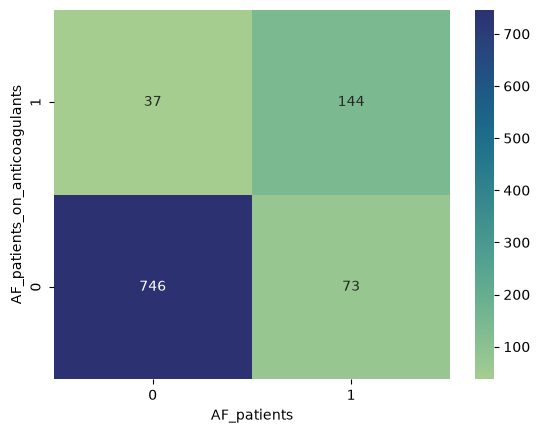

In [18]:
ax=sns.heatmap(df_g, cmap="crest", annot=True,fmt="g")#format- general (not scientific)
ax.invert_yaxis()